# Analyse exploratoire des données (EDA)
## Prédiction de la qualité de l'air — Maroc

Ce notebook explore le dataset fusionné (7 villes, 2099 mesures) **avant**
la préparation et la modélisation faites dans `scripts/02_prepare_data.py`
et suivants. L'objectif : comprendre la distribution de la cible (PM2.5),
détecter les anomalies de collecte, et visualiser les relations entre
variables qui expliquent les résultats obtenus plus tard dans le pipeline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

df = pd.read_csv("../data/morocco_air_quality_data_clean.csv", parse_dates=["timestamp"])
df.shape

(2099, 20)

## 1. Vue d'ensemble

In [2]:
print(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}")
print(f"Villes : {df['city'].nunique()} -> {sorted(df['city'].unique())}")
print(f"Période : {df['timestamp'].min()} -> {df['timestamp'].max()}")
df.head()

Lignes : 2099, Colonnes : 20
Villes : 7 -> ['Agadir', 'Casablanca', 'Fes', 'Karia Ba Mohamed', 'Marrakech', 'Rabat', 'Tanger']
Période : 2026-04-26 12:59:30 -> 2026-05-23 13:19:36


,timestamp,city,lat,lon,temperature,humidity,pressure,wind_speed,weather_description,aqi,no2,o3,pm2_5,pm10,source_file,year,month,day,hour,split
0,2026-04-26 12:59:30,Casablanca,33.5731,-7.5898,21.01,73.0,1011.0,1.54,broken clouds,3.0,0.61,103.01,9.22,19.79,raw_collecte_principale.csv,2026,4,26,12,train
1,2026-04-26 12:59:31,Rabat,34.0209,-6.8416,22.37,78.0,1011.0,3.09,scattered clouds,3.0,1.08,104.71,13.70,20.61,raw_collecte_principale.csv,2026,4,26,12,train
2,2026-04-26 12:59:33,Marrakech,31.6295,-7.9811,24.98,53.0,1009.0,2.06,scattered clouds,2.0,0.36,93.11,9.27,42.58,raw_collecte_principale.csv,2026,4,26,12,train
3,2026-04-26 12:59:35,Fes,34.0331,-5.0003,24.08,56.0,1011.0,4.63,clear sky,2.0,0.17,76.47,4.25,16.94,raw_collecte_principale.csv,2026,4,26,12,train
4,2026-04-26 13:59:36,Casablanca,33.5731,-7.5898,21.01,68.0,1011.0,3.09,scattered clouds,3.0,0.48,107.04,8.63,17.10,raw_collecte_principale.csv,2026,4,26,13,train


In [3]:
df.describe()

,timestamp,lat,lon,temperature,humidity,pressure,wind_speed,aqi,no2,o3,pm2_5,pm10,year,month,day,hour
count,2099,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.000000,2099.0,2099.000000,2099.000000,2099.000000
mean,2026-05-06 18:41:41.032525,33.501435,-6.833536,19.575717,64.917580,1014.780848,3.127585,2.280610,1.185469,92.188795,4.015693,9.645088,2026.0,4.889948,9.472130,14.133873
min,2026-04-26 12:59:30,30.427800,-9.598100,7.370000,15.000000,1005.000000,0.000000,1.000000,0.120000,27.380000,0.720000,1.680000,2026.0,4.000000,1.000000,0.000000
25%,2026-05-02 11:31:08.500000,31.629500,-7.981100,17.370000,54.000000,1012.000000,2.060000,2.000000,0.390000,84.685000,2.415000,5.590000,2026.0,5.000000,3.000000,11.000000
50%,2026-05-05 20:45:06.507749,34.020900,-6.841600,19.640000,64.000000,1015.000000,3.090000,2.000000,0.850000,93.300000,3.360000,7.600000,2026.0,5.000000,7.000000,15.000000
75%,2026-05-10 14:07:01,34.033100,-5.834000,21.370000,77.000000,1017.000000,4.120000,3.000000,1.680000,102.050000,4.660000,10.855000,2026.0,5.000000,13.000000,18.000000
max,2026-05-23 13:19:36,35.759500,-5.000300,38.980000,100.000000,1022.000000,9.500000,3.000000,6.530000,125.690000,21.930000,88.900000,2026.0,5.000000,30.000000,23.000000
std,NaN,1.536766,1.367084,3.530789,15.516754,3.287698,1.540626,0.496758,1.013180,14.104992,2.592066,7.284596,0.0,0.313030,8.164512,5.501858


## 2. Distribution de la cible (PM2.5) par ville

Marrakech ressort avec la médiane et la variance les plus élevées ; Tanger
et Karia Ba Mohamed sont les plus stables et les moins pollués sur la
période observée. Plusieurs valeurs extrêmes (>15 µg/m³) apparaissent à
Casablanca et Rabat, à examiner au cas par cas plutôt qu'à exclure
automatiquement (pas assez de volume pour être sûr qu'il s'agit de bruit
de mesure plutôt que d'un vrai pic de pollution).

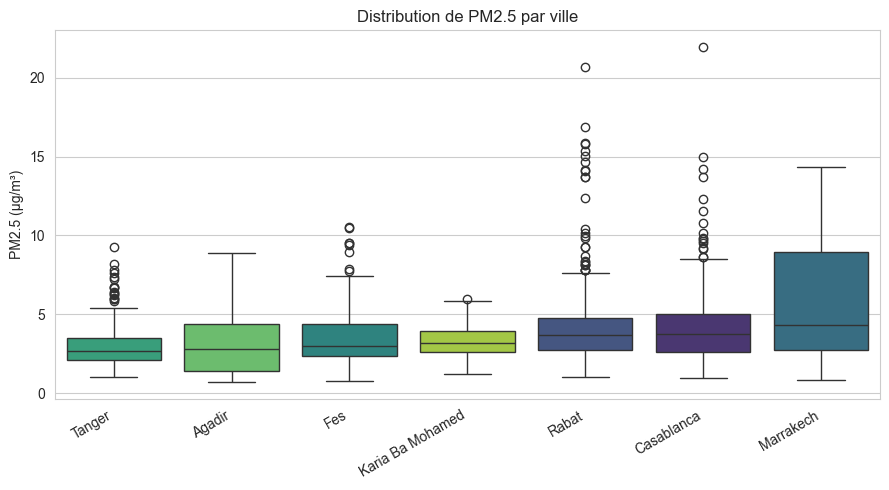

In [4]:
order = df.groupby("city")["pm2_5"].median().sort_values().index

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="city", y="pm2_5", hue="city", order=order,
            palette="viridis", legend=False)
plt.title("Distribution de PM2.5 par ville")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Série temporelle : PM2.5 dans le temps

La zone rouge marque le plus gros trou de collecte détecté dans les
données : **134 heures (~5.6 jours) sans aucune mesure**, du 17 au 23 mai.
Cela correspond probablement à un arrêt de la machine qui faisait tourner
`01_collect_data.py` (portable éteint ou mis en veille). C'est une limite
réelle du dataset à mentionner dans le rapport plutôt qu'à ignorer.

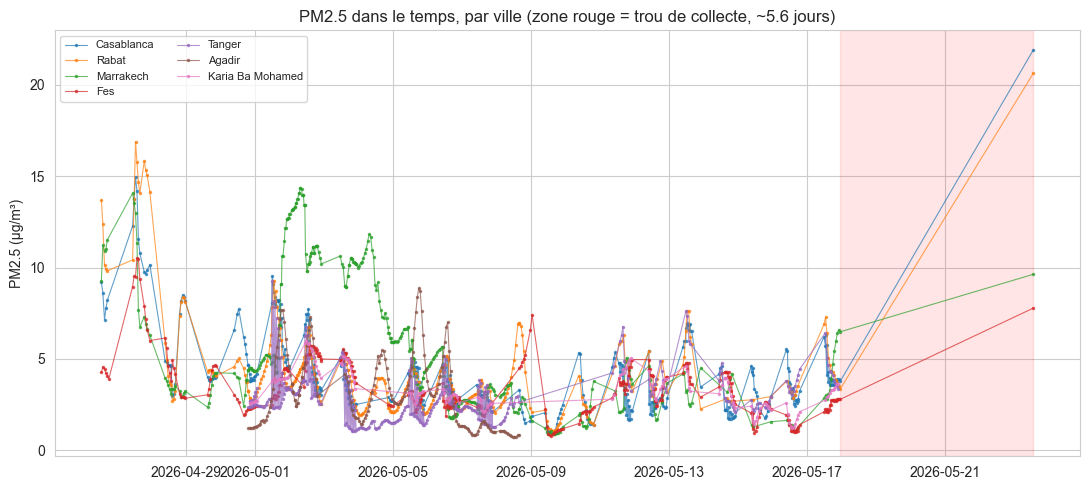

In [5]:
plt.figure(figsize=(11, 5))
for city in df["city"].unique():
    sub = df[df.city == city].sort_values("timestamp")
    plt.plot(sub["timestamp"], sub["pm2_5"], marker=".", linewidth=0.8,
              markersize=3, label=city, alpha=0.7)

plt.axvspan(pd.Timestamp("2026-05-17 23:00"), pd.Timestamp("2026-05-23 13:19"),
            color="red", alpha=0.10)
plt.title("PM2.5 dans le temps, par ville (zone rouge = trou de collecte, ~5.6 jours)")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 4. Corrélations entre variables

Le point le plus important de cette analyse : **`pm10` et `pm2_5` sont
corrélés à 0.87**. C'est de loin la corrélation la plus forte du dataset,
bien plus que n'importe quelle variable météo avec la cible (température
0.25, humidité -0.03, pression 0.00). Ça anticipe et explique pourquoi le
Random Forest entraîné plus tard dans le pipeline s'appuie à 87% sur
`pm10` : le modèle apprend surtout une relation physique entre deux
mesures de particules, pas vraiment un lien météo → pollution.

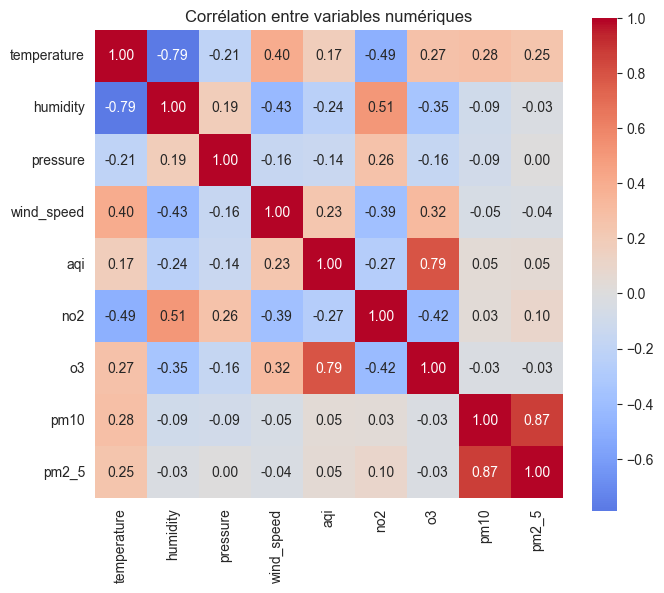

In [6]:
numeric_cols = ["temperature", "humidity", "pressure", "wind_speed",
                "aqi", "no2", "o3", "pm10", "pm2_5"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Corrélation entre variables numériques")
plt.tight_layout()
plt.show()

## 5. Répartition géographique

La taille des points est proportionnelle au nombre de mesures collectées
pour chaque ville (rappel : les 3 sources fusionnées n'ont pas toutes
couvert les mêmes villes). Marrakech ressort comme la ville la plus
polluée en moyenne sur la période, Karia Ba Mohamed et Tanger les moins
polluées.

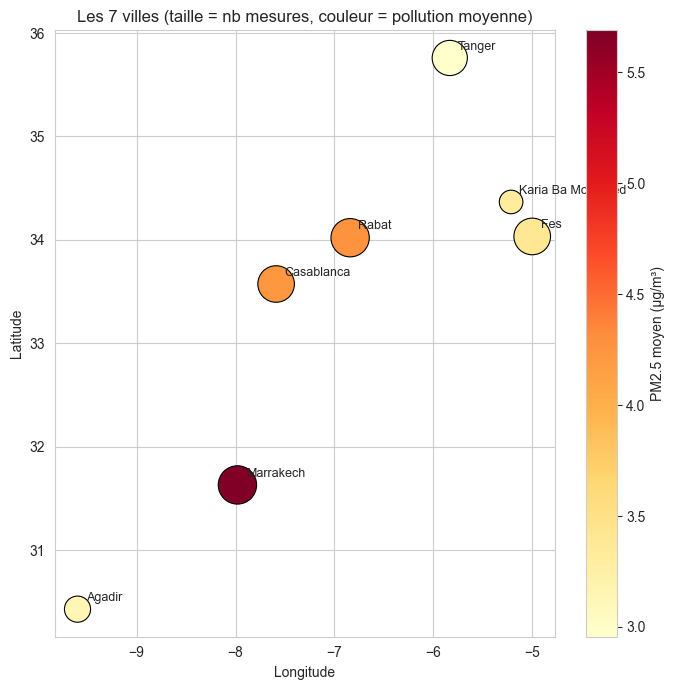

In [7]:
city_stats = (df.groupby("city")
                .agg(lat=("lat", "first"), lon=("lon", "first"),
                     pm25_mean=("pm2_5", "mean"), n=("pm2_5", "count"))
                .reset_index())

plt.figure(figsize=(7, 7))
sc = plt.scatter(city_stats["lon"], city_stats["lat"], s=city_stats["n"] * 2,
                  c=city_stats["pm25_mean"], cmap="YlOrRd",
                  edgecolor="black", linewidth=0.8)
for _, row in city_stats.iterrows():
    plt.annotate(row["city"], (row["lon"], row["lat"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.colorbar(sc, label="PM2.5 moyen (µg/m³)")
plt.title("Les 7 villes (taille = nb mesures, couleur = pollution moyenne)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## 6. Répartition du split train/test

Rappel méthodologique (voir `02_prepare_data.py`) : le split est
**chronologique** (80% le plus ancien = train, 20% le plus récent = test),
pas aléatoire, pour éviter qu'une mesure et celle de l'heure suivante
(quasi identiques) ne se retrouvent des deux côtés du split.

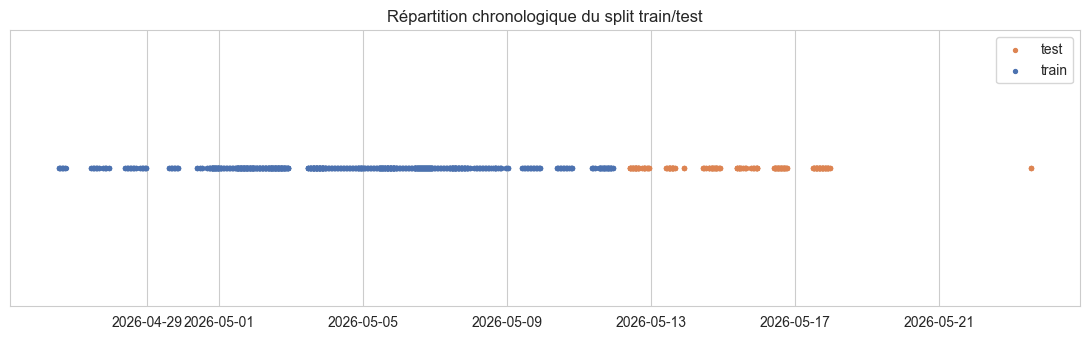

In [8]:
plt.figure(figsize=(11, 3.5))
colors = {"train": "#4C72B0", "test": "#DD8452"}
for split_name, g in df.groupby("split"):
    plt.scatter(g["timestamp"], [1] * len(g), color=colors[split_name],
                s=8, label=split_name)
plt.yticks([])
plt.title("Répartition chronologique du split train/test")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions de l'exploration

- **Marrakech** est la ville la plus polluée et la plus variable sur la
  période ; **Karia Ba Mohamed** et **Tanger** sont les plus stables.
- Un **trou de collecte de ~5.6 jours** (17-23 mai) réduit la couverture
  réelle à 23 des 27 jours de la période — une limite à mentionner dans le
  rapport final.
- **`pm10` est le prédicteur dominant** (corrélation 0.87 avec la cible),
  bien avant toute variable météo — ce qui explique l'importance des
  features observée dans le Random Forest en aval.
- Le split chronologique laisse **Agadir absent du test set** (sa fenêtre
  de collecte se termine avant le début de la période de test), à garder
  en tête en interprétant les résultats par ville.

Ces observations motivent directement les choix faits dans
`02_prepare_data.py` (split chronologique, exclusion des colonnes trop
creuses) et la discussion des limites dans le README.
